#  Day 3: Spark SQL + Advanced DataFrame Ops
🕐 **Total: 2 hours**

| Topic | Notes |
|-------| -------|
| Spark SQL - Overview |  SQL vs DataFrame API |
| Temporary Views | createOrReplaceTempView() |
| SQL Queries on DFs |  Hands-on filtering, aggregation |
| Handling Nulls & Data Types |  fillna, dropna, type casting |
| Window Functions |  row_number(), rank(), lead(), lag() |
| Rows Between, Partitioning |  rowsBetween, partitionBy |
| Lab/Problem Statement |  Hands-on: Rank top N products by revenue or lead-lag sales |

---

RDD vs Dataframes

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("RDD vs DataFrame").getOrCreate()

rdd = spark.sparkContext.textFile("file:///C:/docs/user_profiles.csv")

# Extract header
header = rdd.first()

# Remove header and split CSV rows by comma
data_rdd = rdd.filter(lambda row: row != header).map(lambda row: row.split(","))

# Filter: users from USA and is_active == true
filtered_rdd = data_rdd.filter(
    lambda cols: cols[5] == "USA" and cols[7].strip().lower() == "true"
)

# Select user_id and name
result_rdd = filtered_rdd.map(lambda cols: (cols[0], cols[1]))

print("RDD Result:")
print(result_rdd.collect())


RDD Result:
[('101', 'John Doe'), ('5', 'Michael Brown'), ('7', 'David Lee'), ('11', 'Robert Downey'), ('15', 'Noah Davis'), ('16', 'Mia Clark'), ('23', 'Benjamin Adams'), ('27', 'Henry Mitchell'), ('31', 'Daniel Phillips'), ('35', 'Joseph Edwards'), ('41', 'Andrew Cook'), ('45', 'Christopher Bailey'), ('49', 'Logan Cox')]


In [2]:
# Load the CSV file into a DataFrame
df = spark.read.csv("file:///C:/docs/user_profiles.csv", header=True, inferSchema=True)
filtered_df = df.filter((df["country"] == "USA") & (df["is_active"] == True)).select("user_id", "name")
print("DataFrame Result:")
filtered_df.collect()

DataFrame Result:


[Row(user_id=101, name='John Doe'),
 Row(user_id=5, name='Michael Brown'),
 Row(user_id=7, name='David Lee'),
 Row(user_id=11, name='Robert Downey'),
 Row(user_id=15, name='Noah Davis'),
 Row(user_id=16, name='Mia Clark'),
 Row(user_id=23, name='Benjamin Adams'),
 Row(user_id=27, name='Henry Mitchell'),
 Row(user_id=31, name='Daniel Phillips'),
 Row(user_id=35, name='Joseph Edwards'),
 Row(user_id=41, name='Andrew Cook'),
 Row(user_id=45, name='Christopher Bailey'),
 Row(user_id=49, name='Logan Cox')]

A DataFrame is essentially a table where:
- Rows represent individual data entries (like records or observations).



In [6]:
filtered_df.show(1)

+-------+--------+
|user_id|    name|
+-------+--------+
|    101|John Doe|
+-------+--------+
only showing top 1 row



Comparing Actions in apache Spark 

Brings all rows of the DataFrame to the driver node.
Can crash your driver with OOM (Out of Memory) if the DataFrame is large.

Restricts the number of rows Spark retrieves to just n.
Much safer for inspecting or sampling data.

df.show(10) internally behaves like df.limit(10).collect() — it’s lazy, fast, and truncates output.
But collect() brings all data — even if you later slice it in Python. for RDD's we Use take 

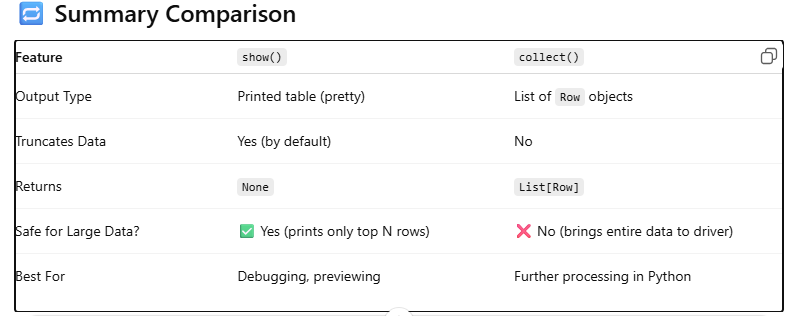

In [3]:
from pyspark.sql import SparkSession

spark=SparkSession.builder \
    .appName("Spark SQL Example") \
    .getOrCreate()

### We should not use InferSchema because 

- Performance Cost
- Inaccuracy or Wrong Guesses
- Inconsistent Schema Across Files
- Less Control

In [4]:
# create a datsframe with a schema
from pyspark.sql.types import StructType, StructField, StringType, IntegerType,DateType,BooleanType
# use feilds to define the schema are user_id ,name, email ,gender, date_of_birth, country, signup_date, is_active, followers_count
import datetime as dt

schema = StructType([
    StructField("user_id", IntegerType(), True),
    StructField("name", StringType(), True),
    StructField("email", StringType(), True),
    StructField("gnder", StringType(), True),
    StructField("date_of_birth", DateType(), True),
    StructField("country", StringType(), True),
    StructField("signup_date", DateType(), True),
    StructField("is_active", BooleanType(), False),
    StructField("followers_count", IntegerType(), True)
])

# Create a DataFrame with the defined schema
data= [1,"rajeev","rajeev@gmial.com","male",dt.date(1993,9,8),"USA",dt.date(2003,7,8),True,1000]

df_with_schema = spark.createDataFrame([data], schema)

# Show the DataFrame with schema
df_with_schema.show()

+-------+------+----------------+-----+-------------+-------+-----------+---------+---------------+
|user_id|  name|           email|gnder|date_of_birth|country|signup_date|is_active|followers_count|
+-------+------+----------------+-----+-------------+-------+-----------+---------+---------------+
|      1|rajeev|rajeev@gmial.com| male|   1993-09-08|    USA| 2003-07-08|     true|           1000|
+-------+------+----------------+-----+-------------+-------+-----------+---------+---------------+



In [5]:
df_with_schema.printSchema()

root
 |-- user_id: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- email: string (nullable = true)
 |-- gnder: string (nullable = true)
 |-- date_of_birth: date (nullable = true)
 |-- country: string (nullable = true)
 |-- signup_date: date (nullable = true)
 |-- is_active: boolean (nullable = false)
 |-- followers_count: integer (nullable = true)



In [9]:
data=[[1,"rajeev",23],
       [2,"suresh",24],
       [3,"ramesh",25],
       [4,"mahesh",26],
       [5,"rajesh",27]]
schema_raw= StructType([
    StructField("id", IntegerType(), True),
    StructField("name", StringType(), True),
    StructField("age", IntegerType(), True)
])
# Create a DataFrame with the defined schema
df_with_single_column = spark.createDataFrame(data, schema_raw)
# Show the DataFrame
df_with_single_column.show()


+---+------+---+
| id|  name|age|
+---+------+---+
|  1|rajeev| 23|
|  2|suresh| 24|
|  3|ramesh| 25|
|  4|mahesh| 26|
|  5|rajesh| 27|
+---+------+---+



In [10]:
csv_df=spark.read.csv("file:///C:/docs/user_profiles.csv", header=True)

# Show the DataFrame read from CSV
csv_df.show()

+-------+---------------+--------------------+------+-------------+---------+-----------+---------+---------------+
|user_id|           name|               email|gender|date_of_birth|  country|signup_date|is_active|followers_count|
+-------+---------------+--------------------+------+-------------+---------+-----------+---------+---------------+
|    101|       John Doe|john.doe@example.com|  Male|   1990-05-15|      USA| 2020-01-10|     true|           1500|
|      2|     Jane Smith|jane.smith@exampl...|Female|   1985-08-20|   Canada| 2019-03-15|     true|           2300|
|      3|   Mark Johnson|mark.johnson@exam...|  Male|   1992-11-05|       UK| 2021-07-01|    false|            800|
|      4|    Emily Davis|emily.davis@examp...|Female|   1995-02-25|    India| 2020-05-20|     true|           1200|
|      5|  Michael Brown|michael.brown@exa...|  Male|   1988-09-12|      USA| 2018-11-30|     true|           4500|
|      6|   Sarah Wilson|sarah.wilson@exam...|Female|   1993-06-18|Austr

In [11]:
csv_df.printSchema()

root
 |-- user_id: string (nullable = true)
 |-- name: string (nullable = true)
 |-- email: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- date_of_birth: string (nullable = true)
 |-- country: string (nullable = true)
 |-- signup_date: string (nullable = true)
 |-- is_active: string (nullable = true)
 |-- followers_count: string (nullable = true)



In [12]:
csv_df= spark.read.csv("file:///C:/docs/user_profiles.csv", header=True, inferSchema=True)
csv_df.printSchema()

root
 |-- user_id: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- email: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- date_of_birth: date (nullable = true)
 |-- country: string (nullable = true)
 |-- signup_date: date (nullable = true)
 |-- is_active: boolean (nullable = true)
 |-- followers_count: integer (nullable = true)



In [32]:
csv_df= spark.read.csv("file:///C:/docs/user_profiles.csv", header=True, schema=schema)
csv_df.printSchema()

root
 |-- user_id: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- email: string (nullable = true)
 |-- gnder: string (nullable = true)
 |-- date_of_birth: date (nullable = true)
 |-- country: string (nullable = true)
 |-- signup_date: date (nullable = true)
 |-- is_active: boolean (nullable = true)
 |-- followers_count: integer (nullable = true)



### Exploding the JSON data

In [15]:
json_df = spark.read.json("file:///C:/docs/posts_and_comments.json",multiLine=True)
# Show the DataFrame read from JSON
json_df.select("comments").show()

+--------------------+
|            comments|
+--------------------+
|[{201, Great post...|
|[{203, Absolutely...|
|[{205, Congrats! ...|
|[{206, Agreed!, 2...|
|[{207, Nice tips!...|
+--------------------+



In [16]:
# explode a json column
from pyspark.sql.functions import explode
temp=json_df.select("comments").select(explode("comments"))
temp.printSchema()

root
 |-- col: struct (nullable = true)
 |    |-- comment_id: string (nullable = true)
 |    |-- comment_text: string (nullable = true)
 |    |-- created_at: string (nullable = true)
 |    |-- user_id: string (nullable = true)



In [17]:
json_df.printSchema()

root
 |-- comments: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- comment_id: string (nullable = true)
 |    |    |-- comment_text: string (nullable = true)
 |    |    |-- created_at: string (nullable = true)
 |    |    |-- user_id: string (nullable = true)
 |-- created_at: string (nullable = true)
 |-- hashtags: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- post_content: string (nullable = true)
 |-- post_id: string (nullable = true)
 |-- user_id: string (nullable = true)



In [36]:
from pyspark.sql.functions import explode
comments=json_df.select("comments").select(explode("comments").alias("c"))
comments = comments.select("c.comment_id", "c.comment_text", "c.created_at")
# Show the exploded comments
comments.show(truncate=False)


+----------+--------------------------+-------------------+
|comment_id|comment_text              |created_at         |
+----------+--------------------------+-------------------+
|201       |Great post!               |2023-10-01T10:05:00|
|202       |Very informative.         |2023-10-01T10:10:00|
|203       |Absolutely, it's powerful.|2023-10-02T12:15:00|
|204       |Thanks for sharing!       |2023-10-02T12:20:00|
|205       |Congrats! How was it?     |2023-10-03T09:45:00|
|206       |Agreed!                   |2023-10-04T14:10:00|
|207       |Nice tips!                |2023-10-05T16:15:00|
|208       |Very useful.              |2023-10-05T16:20:00|
+----------+--------------------------+-------------------+



https://glx.globallogic.com/content-viewer/course-internal/5452f702-9f2c-4b0e-a313-ba8ea79bcb99

### Spark Optimization Strategies

1. Narrow Transformation Vs Wide Transformation

- **Network Overhead:** Wide transformations (like `groupBy`, `join`, `distinct`, `intersection`) require data to be moved between different nodes (shuffling), which is expensive and slow.
- **Increased Disk I/O:** Shuffling often involves writing intermediate data to disk, increasing disk usage and latency.
- **Resource Intensive:** More CPU, memory, and network bandwidth are consumed, which can lead to performance bottlenecks.
- **Potential for Failures:** Large shuffles can cause out-of-memory errors or slow down the entire job.



2. Caching and Persisting 

.cache() is a method used to store the results of a DataFrame or RDD in memory after its first computation

.persist()

Cache Utilizes Cache , but we need to be aware of what we are caching 
To undo this the function used is 

.unpersist()

.persist() :- 

persist() is similar to cache() but offers more control over where/how the data is stored.

Unlike cache() (which stores data only in memory), persist() gives more control over the storage level — you can store in memory, disk, or both.

You can persist data:

- In memory only
- In memory and disk
- On disk only
- In serialized form (compressed)



In [21]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("Spark SQL Example") \
    .getOrCreate()
user_profiles_df = spark.read.csv("file:///C:/docs/user_profiles.csv", header=True, inferSchema=True)

In [22]:
# Perform a wide transformation and cache the result
country_counts = user_profiles_df.groupBy("country").count()
# Cache the result
country_counts.cache()

DataFrame[country: string, count: bigint]

Cache is a transformation need an action to be executed

In [23]:

# First action: triggers computation and caching
country_counts.show()


+---------+-----+
|  country|count|
+---------+-----+
|  Germany|    5|
|   France|    5|
|    India|    7|
|      USA|   13|
|       UK|    7|
|   Canada|    7|
|Australia|    6|
+---------+-----+



In [24]:
# Second action: should use the cache, stage will be skipped in Spark UI
country_counts.filter(country_counts['count'] > 1).show()

+---------+-----+
|  country|count|
+---------+-----+
|  Germany|    5|
|   France|    5|
|    India|    7|
|      USA|   13|
|       UK|    7|
|   Canada|    7|
|Australia|    6|
+---------+-----+



In [25]:
# Third action: again uses cache, stage will be skipped
country_counts.count()

7

In [94]:
# Without cache: Spark may recompute or may skip if in same job
df = user_profiles_df.groupBy("country").count()
df.show()
df.show()  # May skip if in same job, but not guaranteed across jobs

# With cache: Spark will definitely skip recomputation after first action
df = user_profiles_df.groupBy("country").count()
df.cache()
df.show()  # Triggers computation and caches
df.show()  # Will always use cache, stage is skipped

+---------+-----+
|  country|count|
+---------+-----+
|  Germany|    5|
|   France|    5|
|    India|    7|
|      USA|   13|
|       UK|    7|
|   Canada|    7|
|Australia|    6|
+---------+-----+

+---------+-----+
|  country|count|
+---------+-----+
|  Germany|    5|
|   France|    5|
|    India|    7|
|      USA|   13|
|       UK|    7|
|   Canada|    7|
|Australia|    6|
+---------+-----+

+---------+-----+
|  country|count|
+---------+-----+
|  Germany|    5|
|   France|    5|
|    India|    7|
|      USA|   13|
|       UK|    7|
|   Canada|    7|
|Australia|    6|
+---------+-----+

+---------+-----+
|  country|count|
+---------+-----+
|  Germany|    5|
|   France|    5|
|    India|    7|
|      USA|   13|
|       UK|    7|
|   Canada|    7|
|Australia|    6|
+---------+-----+



In [95]:
spark.stop()

### Flow when Cache is applied

| Scenario                                   | Shuffle Stage Happens? | Why                                              |
|--------------------------------------------|-------------------------|--------------------------------------------------|
| **Before cache is populated**              | Yes                     | Wide transformations require shuffle             |
| **During the first action after `.cache()`** | Yes                     | Spark must compute the DataFrame before caching  |
| **All actions after the DataFrame is cached** | No                      | Spark reads from memory, not recomputing stages  |


In [27]:
# use persistence to store the dataframe in memory and disk

from pyspark import StorageLevel
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("Spark SQL Example") \
    .getOrCreate()
user_profiles_df = spark.read.csv("file:///C:/docs/user_profiles.csv", header=True, inferSchema=True)
# Persist the DataFrame in memory and disk
user_profiles_df.persist(StorageLevel.MEMORY_AND_DISK)
# Perform some actions to trigger persistence
user_profiles_df.show()

+-------+---------------+--------------------+------+-------------+---------+-----------+---------+---------------+
|user_id|           name|               email|gender|date_of_birth|  country|signup_date|is_active|followers_count|
+-------+---------------+--------------------+------+-------------+---------+-----------+---------+---------------+
|    101|       John Doe|john.doe@example.com|  Male|   1990-05-15|      USA| 2020-01-10|     true|           1500|
|      2|     Jane Smith|jane.smith@exampl...|Female|   1985-08-20|   Canada| 2019-03-15|     true|           2300|
|      3|   Mark Johnson|mark.johnson@exam...|  Male|   1992-11-05|       UK| 2021-07-01|    false|            800|
|      4|    Emily Davis|emily.davis@examp...|Female|   1995-02-25|    India| 2020-05-20|     true|           1200|
|      5|  Michael Brown|michael.brown@exa...|  Male|   1988-09-12|      USA| 2018-11-30|     true|           4500|
|      6|   Sarah Wilson|sarah.wilson@exam...|Female|   1993-06-18|Austr